# Phân tích Khám phá & Tiền xử lý dữ liệu (EDA & Preprocessing)

**Bối cảnh phân tích (Analytical Context):**
Notebook này thực hiện bước đầu tiên trong pipeline phân tích: Khám phá đặc tính hình học của dữ liệu (EDA) và Tiền xử lý. 

Tư duy phân tích ở mức Đánh giá (Evaluate):
1. **EDA**: Thay vì chỉ vẽ biểu đồ dạng summary, chúng ta phân tích hình dáng phân phối (Distribution shape) của Năng suất (Yield) và tương quan phi tuyến (nếu có) giữa các yếu tố thời tiết/hoá chất với Yield. Liệu sâu bệnh và lượng mưa có tác động đồng thời không?
2. **Xử lý ngoại lai (Outliers) & Thiếu dữ liệu**: Trong nông nghiệp, một vụ mùa hoàn toàn mất trắng (Yield = 0) hoặc cực cao đều mang ý nghĩa quan trọng, không nên bị cắt bỏ (drop) một cách mù quáng bằng IQR/Z-score cơ bản. Do đó, việc xác định "dị thường" (anomaly) phải có căn cứ. Ở đây, quyết định giữ lại các giá trị Yield thấp nhưng drop nếu missing hoặc vô lý (âm).
3. **Chuẩn hoá (Scaling) & Rời rạc hoá (Discretization)**:
   - Để mô hình khoảng cách (clustering) và các mô hình tuyến tính hoạt động tốt, Standard Scaling (Z-score) thường phù hợp do phân phối tự nhiên của lượng mưa và nhiệt độ có xu hướng quần tụ. Trừ phi Dữ liệu có dạng power-law, Z-score giúp đưa các unit (hg/ha, mm, celsius, tonnes) về chung không gian metric.
   - Để khai phá tập phổ biến (Association Rules), thuật toán yêu cầu items rời rạc. Việc chia bns phải dựa trên tính thực tế sinh học (ví dụ: nhiệt độ < 15, 15-25, >25 độ C).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import warnings
warnings.filterwarnings('ignore')

# Style for stunning vibes
sns.set_theme(style="darkgrid", rc={"axes.facecolor":"#121212", "figure.facecolor":"#121212", 
                                    "axes.edgecolor":"#333333", "grid.color":"#333333",
                                    "text.color":"white", "axes.labelcolor":"white", 
                                    "xtick.color":"white", "ytick.color":"white"})
plt.rcParams["font.family"] = "sans-serif"

## 1. Load Cấu hình & Dữ liệu

In [2]:
with open("../configs/params.yaml", "r") as f:
    config = yaml.safe_load(f)

# Đảm bảo thư mục lưu trữ tồn tại
os.makedirs("../" + config['data']['processed_path'], exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

df = pd.read_csv("../" + config['data']['raw_path'])
print(f"Bản ghi ban đầu: {df.shape}")
display(df.head())

Bản ghi ban đầu: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 2. Data Cleaning
Tiến hành làm sạch:
- Xóa dòng trùng lặp (duplicates).
- Xử lý giá trị rỗng/NA.
- Loại bỏ các bản ghi Yield hoặc Rainfall <= 0 (nếu có) vì trong nông nghiệp, ghi nhận 0 lượng mưa cho cả năm có thể là lỗi thu thập dữ liệu tự động.

In [3]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df = df[(df['hg/ha_yield'] > 0)]
# Đổi tên cột cho trực quan
df.rename(columns={
    'hg/ha_yield': 'Yield',
    'average_rain_fall_mm_per_year': 'Rainfall',
    'pesticides_tonnes': 'Pesticides',
    'avg_temp': 'Avg_Temperature'
}, inplace=True)

# Sửa lỗi type nếu Rainfall đang là object (do có thể chứa string lẫn kí tự đặc biệt)
# Hàm ép kiểu
def clean_numeric(val):
    try:
        if pd.isna(val): return np.nan
        # Xoá khoảng trắng và ép float
        return float(str(val).strip())
    except:
        return np.nan

df['Rainfall'] = df['Rainfall'].apply(clean_numeric)
df.dropna(subset=['Rainfall'], inplace=True)

print(f"Bản ghi sau khi Clean: {df.shape}")

Bản ghi sau khi Clean: (28242, 8)


## 3. EDA Khám phá Sâu (In-depth EDA)

### Biểu đồ 1: Phân phối năng suất (Yield Distribution)
Hình dạng phân phối gợn thế nào? Tính toán Skewness giúp xác định độ lệch. Một phân phối lệch phải (Right-skewed) cho thấy các vụ mùa năng suất cực cao (đột biến) ít xảy ra. Đánh giá: Giúp ta chọn Metric mô hình sau này (nên tránh RMSE nếu đuôi quá dài).

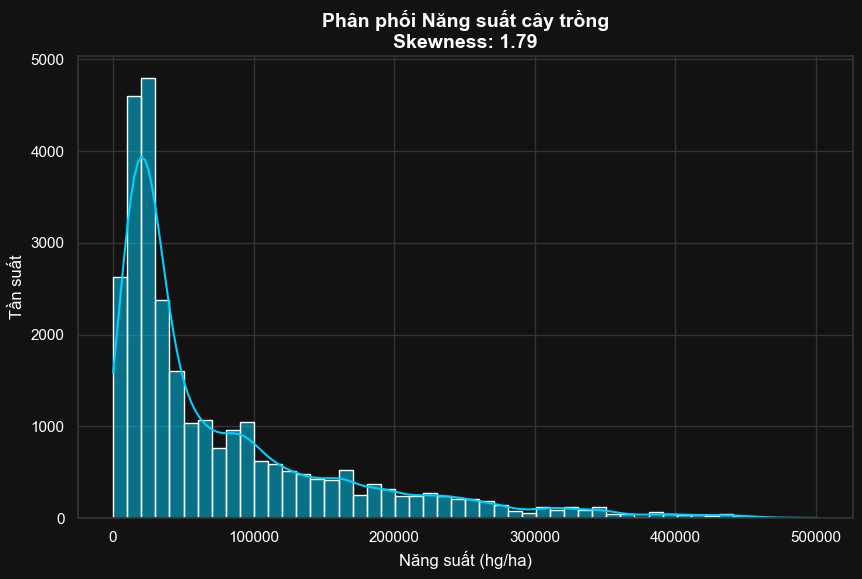

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield'], kde=True, bins=50, color='#00d0ff')
plt.title(f"Phân phối Năng suất cây trồng\nSkewness: {df['Yield'].skew():.2f}", fontsize=14, fontweight='bold')
plt.xlabel("Năng suất (hg/ha)")
plt.ylabel("Tần suất")
plt.savefig("../outputs/figures/eda_yield_dist.png", dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ 2: Scatter Tương quan Nhiệt độ - Lượng mưa - Năng suất (3D mapping in 2D)
Tư duy phân tích: Không chỉ xem xét tương quan cặp (pairwise). Liệu "Nhiệt độ Mát + Lượng Mưa Cao" có luôn tốt? Biểu đồ này dùng kích thước (size) và màu (hue) để mapping đa chiều.

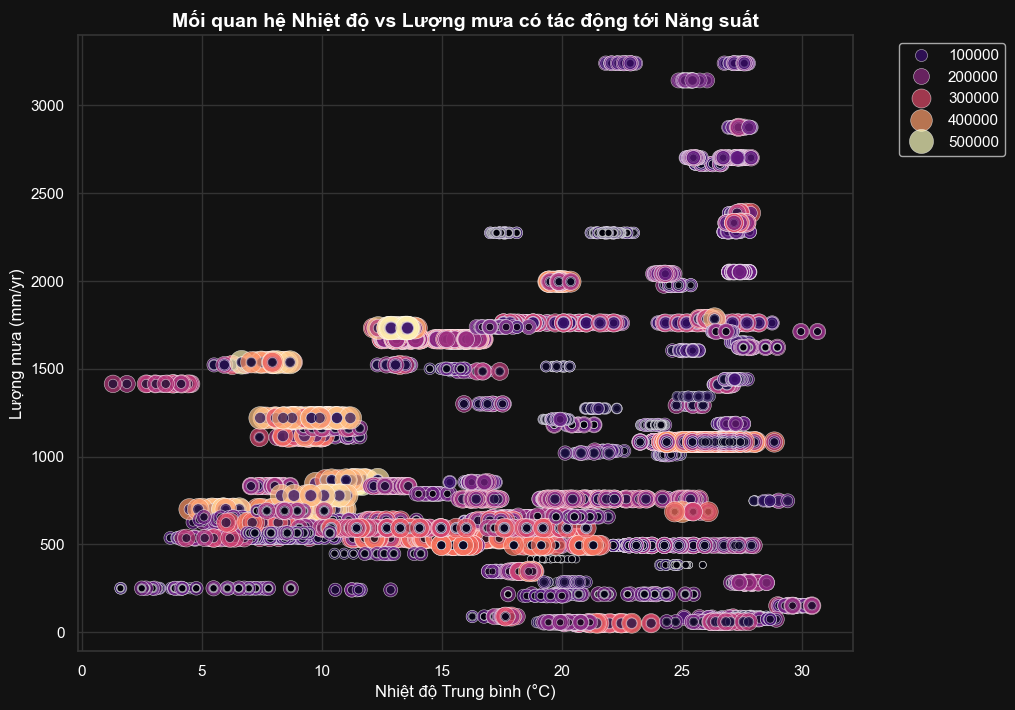

In [5]:
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    data=df, x='Avg_Temperature', y='Rainfall', hue='Yield', 
    size='Yield', sizes=(20, 300), palette='magma', alpha=0.7
)
plt.title("Mối quan hệ Nhiệt độ vs Lượng mưa có tác động tới Năng suất", fontsize=14, fontweight='bold')
plt.xlabel("Nhiệt độ Trung bình (°C)")
plt.ylabel("Lượng mưa (mm/yr)")
# Move legend to outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("../outputs/figures/eda_temp_rain_yield.png", dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ 3: Nhiệt độ trung bình theo các Quốc gia có năng suất lớn nhất
Đánh giá vĩ mô: Nông nghiệp bị ảnh hưởng rất mạnh bởi đới khí hậu địa lý. Khám phá nhóm Top 10 Quốc gia năng suất cao.

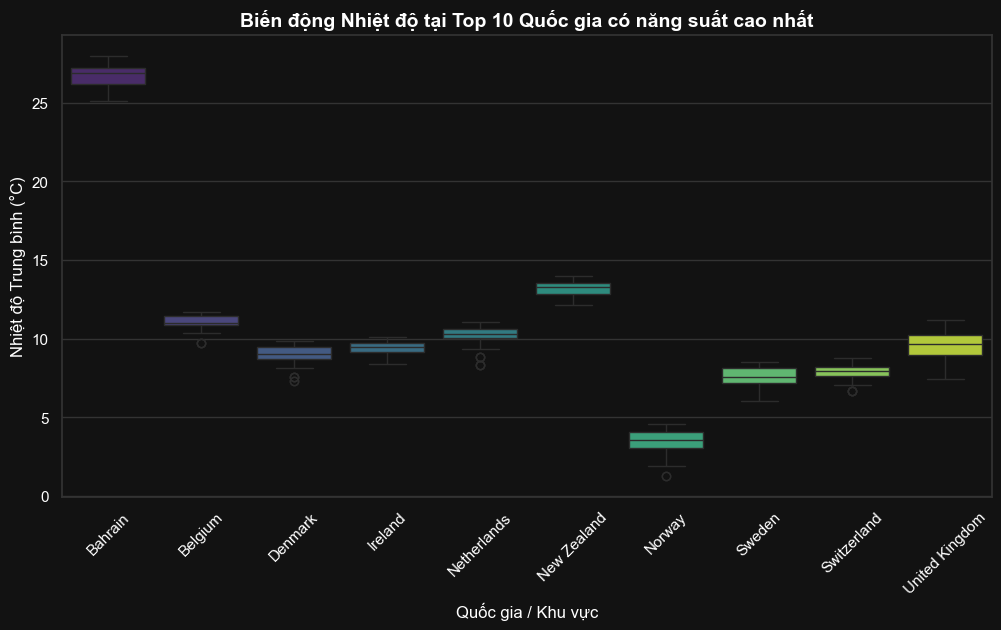

In [6]:
top_10_countries = df.groupby('Area')['Yield'].mean().sort_values(ascending=False).head(10).index
subset_top = df[df['Area'].isin(top_10_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset_top, x='Area', y='Avg_Temperature', palette='viridis')
plt.title("Biến động Nhiệt độ tại Top 10 Quốc gia có năng suất cao nhất", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel("Quốc gia / Khu vực")
plt.ylabel("Nhiệt độ Trung bình (°C)")
plt.savefig("../outputs/figures/eda_top10_temp.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Tiền xử lý (Preprocessing)
Giai đoạn này ta tiến hành:
1. Standard Scaling cho dữ liệu mô hình hoá (Hồi quy / Phân cụm mật độ). Z-score scaling chịu ảnh hưởng bởi outliers, nhưng vì dải giá trị của Yield và Pesticides quá rộng nên việc log-transform có thể cần thiết nếu xây mô hình tuyến tính, tuy nhiên ở đây ta dùng Standard cho tính bảo toàn phân phối (đặc biệt phù hợp vs K-Means/Tree-based models).
2. Rời rạc hoá cho Khai phá luật kết hợp (Association Rules). Dùng Pandas `qcut/cut` để chia các vùng thuộc tính.

Tư duy: Rời rạc hoá (Discretization) làm mất thông tin liên tục, do đó ta phải giữ lại bản copy dữ liệu số nguyên gốc để chạy mô hình hồi quy. File rời rạc chỉ dùng riêng cho Market Basket Analysis.

In [7]:
from sklearn.preprocessing import StandardScaler

# Chép ra 1 bản để scale
df_scaled = df.copy()

num_cols = ['Yield', 'Rainfall', 'Pesticides', 'Avg_Temperature']
scaler = StandardScaler()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

# Lưu dữ liệu phục vụ Models
df_scaled.to_csv(os.path.join("../" + config['data']['processed_path'], "scaled_data.csv"), index=False)
print("Saved scaled_data.csv for Modeling/Clustering.")

Saved scaled_data.csv for Modeling/Clustering.


In [8]:
# Rời rạc hoá cho Association Rules
df_rules = df.copy()

# Cách chia Bins (phân phối lượng):
# Lượng mưa: qcut vào 3 bins (Thấp, Vừa, Cao)
df_rules['Rainfall_Bin'] = pd.qcut(df_rules['Rainfall'], q=3, labels=['Rain_Low', 'Rain_Med', 'Rain_High'])

# Nhiệt độ: cut theo tiêu chuẩn sinh học thay vì phân vị (Lạnh <15, Mát 15-25, Nóng >25)
df_rules['Temp_Bin'] = pd.cut(df_rules['Avg_Temperature'], bins=[-np.inf, 15, 25, np.inf], labels=['Temp_Cold', 'Temp_Warm', 'Temp_Hot'])

# Thuốc trừ sâu: qcut (Dùng ít, Vừa, Nhiều)
df_rules['Pest_Bin'] = pd.qcut(df_rules['Pesticides'], q=3, labels=['Pest_Low', 'Pest_Med', 'Pest_High'])

# Yield (Label Output)
df_rules['Yield_Bin'] = pd.qcut(df_rules['Yield'], q=3, labels=['Yield_Low', 'Yield_Med', 'Yield_High'])

cols_to_keep = ['Area', 'Item', 'Rainfall_Bin', 'Temp_Bin', 'Pest_Bin', 'Yield_Bin']
df_rules = df_rules[cols_to_keep]

df_rules.to_csv(os.path.join("../" + config['data']['processed_path'], "discretized_data.csv"), index=False)
print("Saved discretized_data.csv for Association Rules.")

display(df_rules.head())

Saved discretized_data.csv for Association Rules.


,Area,Item,Rainfall_Bin,Temp_Bin,Pest_Bin,Yield_Bin
0,Albania,Maize,Rain_High,Temp_Warm,Pest_Low,Yield_Med
1,Albania,Potatoes,Rain_High,Temp_Warm,Pest_Low,Yield_Med
2,Albania,"Rice, paddy",Rain_High,Temp_Warm,Pest_Low,Yield_Low
3,Albania,Sorghum,Rain_High,Temp_Warm,Pest_Low,Yield_Low
4,Albania,Soybeans,Rain_High,Temp_Warm,Pest_Low,Yield_Low


### Kết luận bước EDA & Preprocessing
- Chúng ta đã ghi nhận sự mất cân bằng trong dãy phân phối Năng suất (đuôi dài mũi nhọn).
- Không xoá bỏ dị thường vì trong nông nghiệp, các "cú sốc" (dịch bệnh, hạn hán) là nguyên nhân gây nhiễu hợp lý và mô hình cần phải học được.
- Dữ liệu đã chia nhánh: một nhánh cho Thuật toán rời rạc (Apriori/FP-Growth), một nhánh cho Thuật toán điểm khoảng cách (Clustering/Regression).